### r: Denudation and Vegetation cover

In [7]:
import pandas as pd
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import numpy as np
import math
import os
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [ ]:
# settings
work_directory = r'C:\Users\...\Code'

os.chdir(work_directory)

# setting: font
font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)  # pass in the font dict as kwargs

In [ ]:
# loading data

data_directory = '.../basins_5245.csv'
original_data = pd.read_table(data_directory, sep=',', header=0, index_col='OBSID1')
columns_of_interest = ['EBE_MMKYR', 'EBE_ERR', 'GLA_PCNT', 'MATERIAL', 'AREA', 'SLP_deg', 'ELEV_AVE', 'QTZ_PCNT',
                       'SLP_AVE','rock_major', 'rock_count', 'MAP', 'MAT', 'AI', 'NDVI_STS']

data0 = original_data[columns_of_interest].copy()
data0["NDVI"] = data0["NDVI_STS"]

# exclude nodata
Nodata = data0[['MAP', 'NDVI']].isin([-9999]).any(axis=1)
data0 = data0[~Nodata]

# restrict sample materials to "sand" only
data0 = data0[data0['MATERIAL'].isin(['Sa', 'Sed'])]

# depending on the resolution of raster data is about 1 km
data0 = data0[data0['AREA'] > 10]
data0 = data0[data0['AREA'] < 1000]

# denudation, precipitation, and area
data0 = data0[data0['EBE_MMKYR'] >= data0['EBE_MMKYR'].quantile(0.05)]
data0 = data0[data0['EBE_MMKYR'] <= data0['EBE_MMKYR'].quantile(0.95)]

# MAP
data0 = data0[data0['MAP'] <= data0['MAP'].quantile(0.90)]

data0
# data0['NDVI'].describe()
# data0['MAP'].describe()

,EBE_MMKYR,EBE_ERR,GLA_PCNT,MATERIAL,AREA,SLP_deg,ELEV_AVE,QTZ_PCNT,SLP_AVE,rock_major,rock_count,MAP,MAT,AI,NDVI_STS,NDVI
OBSID1,,,,,,,,,,,,,,,,
S141WTS002,23.53,4.24,9.62,Sa,270.30,15.435900,5513.65,1.0,276.12,mt,51.0,176.154999,-8.439930,1909.099976,0.096232,0.096232
S075WTS009,244.15,47.62,0.01,Sa,238.04,22.651800,1348.00,100.0,417.32,mt,72.0,1644.180054,3.924200,17418.500000,0.737846,0.737846
S304WTS005,903.41,170.07,8.13,Sa,257.45,28.607599,2457.29,30.0,545.39,mt,74.0,1142.030029,0.114006,13731.299805,0.407215,0.407215
S293WTS010,818.55,149.97,13.90,Sa,284.95,26.072001,4791.19,78.0,489.29,pa,78.0,668.109985,-2.454970,8520.120117,0.201538,0.201538
S101WTS021,33.97,6.16,7.83,Sa,208.89,24.919600,4721.40,100.0,464.60,pa,85.0,110.887001,-4.870720,1140.030029,0.109365,0.109365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S281WTS029,8.27,1.99,0.00,Sa,10.86,6.461780,313.59,100.0,113.26,sm,100.0,808.786011,18.387800,4630.500000,0.702000,0.702000
S299WTS004,14.77,3.33,0.00,Sa,34.13,11.056300,371.56,100.0,195.40,pa,100.0,1147.819946,10.992100,10569.799805,0.845244,0.845244
S162WTS004,9.94,2.55,0.00,Sa,28.26,1.118840,281.20,100.0,19.53,pa,97.0,665.843994,23.463900,3067.489990,0.467172,0.467172


In [10]:
def get_correlation_coefficient(data,
                                slope_windowsize=10,
                                precipitation_range=[],
                                denudation_field='EBE_MMKYR',
                                slope_field='SLP_deg',
                                precipitation_field='MAP',
                                NDVI_field='NDVI'):
    ## define some parameters
    r_corr = []
    r_error = []
    Slope_window = []
    Precip_window = []
    Number_samples = []
    P_value = []
    NDVI_distribution = []
    i = 0

    slope_max = math.ceil(data[slope_field].max())

    while i < (slope_max-slope_windowsize+1):
        
        ## control variables
        data_copy = data
        # precipitation
        data_copy = data_copy[precipitation_range[0] <= data_copy[precipitation_field]]
        data_copy = data_copy[data_copy[precipitation_field] <= precipitation_range[1]]

        # slope window, moving step=10
        data_copy = data_copy[i <= data_copy[slope_field]]
        data_copy = data_copy[data_copy[slope_field] <= i+slope_windowsize]
        
        ## calculation
        r_iteration = []
        p_iteration = []
        for _ in range(100):
            # pearson r: precipitation and Denudation; and p-value
            random_numbers = np.random.uniform(0.7, 1.3, size=data_copy.shape[0])
            denudation_with_error = data_copy[denudation_field]*random_numbers
            # logsrithmic transformation
            denudation_with_error_log = denudation_with_error.apply(math.log)
            # r calculation
            r, p = stats.pearsonr(denudation_with_error_log, data_copy[NDVI_field])
            # r, p = stats.spearmanr(denudation_with_error_log, data_copy[NDVI_field])
            r_iteration.append(r)
            p_iteration.append(p)

        r_corr.append(round(np.mean(r_iteration), ndigits=4))
        r_error.append(round(np.std(r_iteration, ddof=0), ndigits=4))
        P_value.append(np.mean(p_iteration))
        
        ## recording r's corresponding 'slope window'
        Slope_tuple = [i, i+slope_windowsize]
        Slope_window.append(Slope_tuple)

        ## recording r's corresponding 'precipitation window'
        Precip_window.append(precipitation_range)
        
        ## recording the volume of samples on each slope window
        Number_samples.append(data_copy.shape[0])

        ## recording NDVI distribution on each slope window
        NDVI_distribution.append(data_copy[NDVI_field])
        
        ## moving slope window with moving step=10 degrees
        i = i+1
        
    ## generate a new data_copy frame
    df_r = pd.DataFrame({
        "r" : r_corr,
        "r_std" : r_error,
        "P" : P_value,
        "Number" : Number_samples,
        "Slope": Slope_window,
        "Precip" : Precip_window
    })

    # output the data within the NDVI window
    data_selected = data
    data_selected = data_selected[precipitation_range[0] <= data_selected[precipitation_field]]
    data_selected = data_selected[data_selected[precipitation_field] <= precipitation_range[1]]
    
    return df_r, data_selected, NDVI_distribution

In [ ]:
def r_plot(precipitation_range,df_r,data):

    fig, ax = plt.subplots(nrows=1, ncols=1, sharex=True, figsize=(5.5, 2), facecolor='white', dpi=100)

    colors = np.where(df_r['P'] < 0.05, 'royalblue', 'gray')

    y = df_r['r']
    y_error = df_r['r_std']
    x = np.arange(df_r.shape[0])

    for i in range(len(y)):
        ax.errorbar(x[i], y[i], yerr=y_error[i], fmt='.', capsize=2, capthick=0.5, markersize=3,
                color=colors[i], label='Pearson\'r with error bar' if i == 0 else "") 

    # ax.errorbar(x, y, yerr=y_error, fmt='.', color=colors, markersize=5, capsize=3, capthick=1, label='Pearson\'r with error bars')
    ax.axhline(y=0, color='red', linestyle='-', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(df_r['Slope'], rotation=90)
    ax.set_ylim(-1, 1)
    ax.set_yticks(np.arange(-1, 1.2, 0.2))
    ax.grid(True, linestyle=':', axis='x', linewidth=0.5)
    ax.annotate('MAP$\in$[{},{}]; N={}; Mean NDVI={}; Mean MAP={} mm'.format(precipitation_range[0],precipitation_range[1],data.shape[0],
                                                                                                round(data[['NDVI']].apply(np.mean).iloc[0], 2),
                                                                                                int(data[['MAP']].apply(np.mean).iloc[0])), (0,0.8))
    ax.set_title('A', loc='left', fontsize=10, fontweight='bold')
    ax.set_xlabel('10° slope window (°)'
                  , fontsize=8, y=0.02, fontweight='bold')
    ax.set_ylabel('Pearson’s r between Denudation and NDVI'
                  , fontsize=8, x=0.02, fontweight='bold')
    # plt.savefig("Results/260309/Figure S4A.png", dpi=150, transparent=False, bbox_inches='tight', pad_inches=0.1)

    return

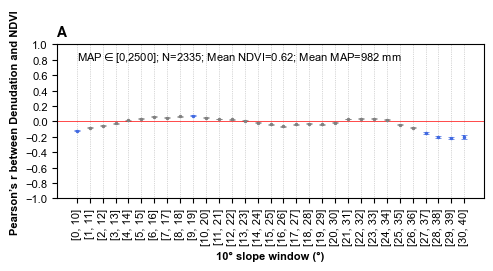

In [12]:
df_r1, data1, NDVI_dis1 = get_correlation_coefficient(data0,
                                slope_windowsize=10,
                                precipitation_range=[0, 2500],
                                denudation_field='EBE_MMKYR',
                                slope_field='SLP_deg',
                                precipitation_field='MAP',
                                NDVI_field='NDVI')
# df_r1
r_plot(precipitation_range=[0, 2500], df_r=df_r1, data=data1)